In [57]:
import numpy as np
import pandas as pd
import tensorflow as tf
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [103]:
train_dir = "../dataset/flower-sm-dataset/train"  
test_dir = "../dataset/flower-sm-dataset/test"

In [104]:
import os
print(os.listdir(train_dir))
print(os.listdir(test_dir))

['daisy', 'dandelion']
['daisy', 'dandelion']


### Purpose

- ImageDataGenerator is used for data augmentation and real-time data feeding for images in deep learning.

- Data augmentation → artificially increase the size and diversity of your training dataset by transforming images (rotation, flipping, zoom, etc.).

- Normalization → scale pixel values (e.g., 0–255 → 0–1) automatically.

- Batch feeding → loads images in batches directly from disk or arrays, saving memory.

In [105]:
train_datagen = ImageDataGenerator(
    rescale=1./255,             # normalize pixels
    rotation_range=20,          # randomly rotate images ±20 degrees
    width_shift_range=0.2,      # randomly shift horizontally ±20%
    height_shift_range=0.2,     # randomly shift vertically ±20%
    shear_range=0.2,            # shear transformation
    zoom_range=0.2,             # random zoom
    horizontal_flip=True,       # flip images horizontally
    vertical_flip=True,         # flip images vertically
    fill_mode='nearest'         # fill missing pixels after transformation
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),   # resize images to 224x224
    class_mode='categorical',
    batch_size=32,
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),   # resize images to 224x224
    class_mode='categorical',
    batch_size=32,
)


Found 1275 images belonging to 2 classes.
Found 182 images belonging to 2 classes.


In [106]:
train_generator.class_indices

{'daisy': 0, 'dandelion': 1}

In [107]:
test_generator.class_indices

{'daisy': 0, 'dandelion': 1}

In [108]:
train_datagen

In [109]:
# Build AlexNet Architechure
def AlexNet(num_classes):
    model = Sequential([
        # Layer 1
        Conv2D(96, kernel_size=(11, 11), strides=4, activation="relu", input_shape=(224, 224, 3)), 
        BatchNormalization(),
        MaxPooling2D(pool_size=(3,3), strides=2), 

        # Layer 2
        Conv2D(256, kernel_size=(5, 5), padding="same", activation="relu"),
        BatchNormalization(),
        MaxPooling2D(pool_size=(3,3), strides=2),

        # Layer 3
        Conv2D(384, kernel_size=(3,3), padding="same", activation="relu"), 

        # Layer 4
        Conv2D(384, kernel_size=(3,3), padding="same", activation="relu"), 

        # Layer 5
        Conv2D(256, kernel_size=(3,3), padding="same", activation="relu"), 
        MaxPooling2D(pool_size=(3, 3), strides=2),

        # Flatten
        Flatten(),

        # FC1
        Dense(4096, activation='relu'),
        Dropout(0.5),

        # FC2
        Dense(4096, activation='relu'),
        Dropout(0.5),

        # Output layer
        Dense(num_classes, activation='sigmoid')
    ])
    
    return model

In [110]:
num_classes = train_generator.num_classes
model = AlexNet(num_classes)
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_30 (Conv2D)              │ (None, 54, 54, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 54, 54, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 26, 26, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 26, 26, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 12, 12, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 12, 12, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 12, 12, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 4096)           │    26,218,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 2)              │         8,194 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,756,610 (178.36 MB)

 Trainable params: 46,755,906 (178.36 MB)

 Non-trainable params: 704 (2.75 KB)

In [111]:
# Compile the model
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

#### Model Evaluation

In [112]:
# Train the model
history = model.fit(
    train_generator, 
    epochs=10,
    validation_data=test_generator
)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.5780 - loss: 2.9913 - val_accuracy: 0.4341 - val_loss: 0.8820
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.6282 - loss: 0.6547 - val_accuracy: 0.5989 - val_loss: 0.6776
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.7027 - loss: 0.6108 - val_accuracy: 0.5440 - val_loss: 0.8085
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.7467 - loss: 0.5542 - val_accuracy: 0.5769 - val_loss: 0.8732
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.7655 - loss: 0.5149 - val_accuracy: 0.6209 - val_loss: 0.7453
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.7804 - loss: 0.4786 - val_accuracy: 0.5824 - val_loss: 0.7286
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.7796 - loss: 0.4887 - val_accuracy: 0.7582 - val_loss: 0.5553
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.7796 - loss: 0.4905 - val_accuracy: 0.6923 - val_loss:

In [113]:
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test accuracy: {test_accuracy}")
print(f"Test Loss: {test_loss}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 204ms/step - accuracy: 0.7912 - loss: 0.4844
Test accuracy: 0.791208803653717
Test Loss: 0.48436644673347473


In [114]:
# save the model
model.save("alexnet_custom_dataset_model.h5")

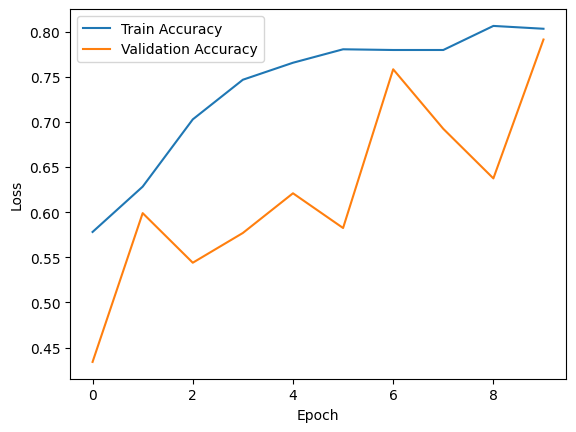

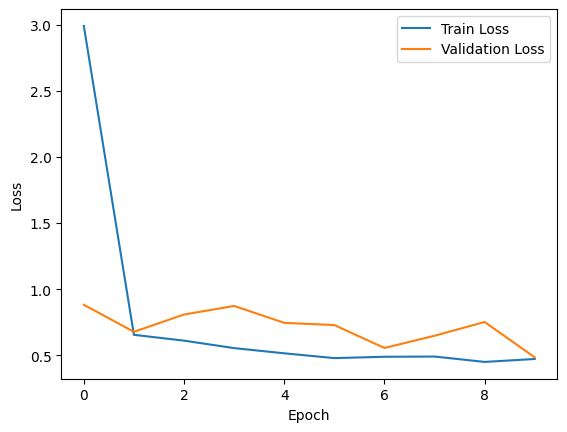

In [115]:
# Visualize the training History
plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Visualize the training History
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [116]:
from tensorflow.keras.utils import load_img, img_to_array

In [117]:

def prediction_image(model, image_path, class_names):

    img = load_img(image_path, target_size=(224, 224))
    img_array = img_to_array(img)/255.0 # Normalize the image
    img_array = np.expand_dims(img_array, axis=0) # expand dimension to match model input
    
    # Predict the class probabilities
    prediction = model.predict(img_array)

    print("predictions --", prediction[0])

    # Get the index of the class with the highest probability
    predicted_class_index = np.argmax(prediction[0])

    print("predicted index", predicted_class_index)

    # Get the predicted class name
    predicted_class = class_names[predicted_class_index]

    return predicted_class


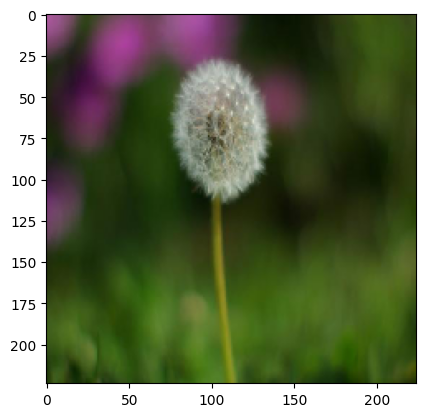

In [122]:
image_path = "../dataset/flower-sm-dataset/test/dandelion/3998275481_651205e02d_jpg.rf.88b1566a4548a5bb7d98b224534fefa0.jpg"
# image_path = "../dataset/flower-sm-dataset/test/daisy/1342002397_9503c97b49_jpg.rf.8fe6bdd23186b70f089bb0c5b89d314e.jpg" 
imgssss = load_img(image_path, target_size=(224, 224))
plt.imshow(imgssss)

In [123]:
class_names = ['daisy', 'dandelion'] 
predicted_class = prediction_image(model, image_path, class_names)
print(f"Predicted class {predicted_class}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
predictions -- [0.32379705 0.6733731 ]
predicted index 1
Predicted class dandelion
